## Business Insights

- Der Umsatz ist über die Jahre insgesamt gestiegen. 2014 hatte den höchsten Umsatz und Gewinn.
- Technology ist die profitabelste Kategorie.
- Furniture erzielt einen hohen Umsatz, hat aber eine sehr niedrige Gewinnmarge.
- Tables und Bookcases verursachen Verluste.
- Rabatte über 20 % sind insgesamt nicht rentabel.
- West ist die profitabelste Region.
- Central hat die niedrigste Gewinnmarge. Hohe Rabatte spielen dort wahrscheinlich eine wichtige Rolle.
- Consumer bringt den höchsten Gesamtgewinn. Home Office hat jedoch die höchste Gewinnmarge.
- November und Dezember sind besonders starke Verkaufsmonate.
- Juli 2011 und Januar 2012 waren die einzigen Monate mit Verlust.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "Superstore/Superstore.csv",
    encoding="latin1"
)

In [2]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.shape

(9994, 21)

In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed",
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="mixed",
    dayfirst=True
)

In [7]:
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2013-11-09,2013-11-12
1,2013-11-09,2013-11-12
2,2013-06-13,2013-06-17
3,2012-10-11,2012-10-18
4,2012-10-11,2012-10-18


In [8]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [11]:
df[["Sales", "Quantity", "Discount", "Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [12]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()

total_sales, total_profit, total_orders

(np.float64(2297200.8603000003), np.float64(286397.0217), 5009)

In [13]:
print(f"Gesamtumsatz: {total_sales:,.2f}")
print(f"Gesamtgewinn: {total_profit:,.2f}")
print(f"Bestellungen: {total_orders:,}")

Gesamtumsatz: 2,297,200.86
Gesamtgewinn: 286,397.02
Bestellungen: 5,009


In [14]:
profit_margin = total_profit / total_sales * 100

print(f"Gewinnmarge: {profit_margin:.2f} %")

Gewinnmarge: 12.47 %


In [15]:
df["Year"] = df["Order Date"].dt.year
df[["Order Date", "Year"]].head()

,Order Date,Year
0,2013-11-09,2013
1,2013-11-09,2013
2,2013-06-13,2013
3,2012-10-11,2012
4,2012-10-11,2012


In [16]:
sales_by_year = df.groupby("Year")["Sales"].sum()

sales_by_year

Year
2011    484247.4981
2012    470532.5090
2013    608473.8300
2014    733947.0232
Name: Sales, dtype: float64

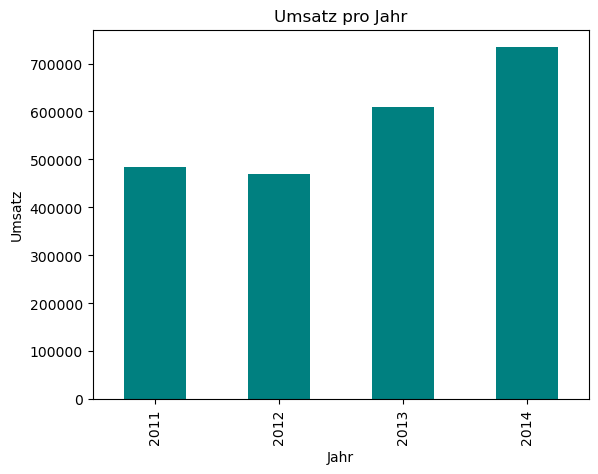

In [17]:
import matplotlib.pyplot as plt
sales_by_year.plot(kind="bar", color="teal")

plt.title("Umsatz pro Jahr")
plt.xlabel("Jahr")
plt.ylabel("Umsatz")
plt.show()

In [18]:
profit_by_year = df.groupby("Year")["Profit"].sum()

profit_by_year

Year
2011    49543.9741
2012    61618.6037
2013    81726.9308
2014    93507.5131
Name: Profit, dtype: float64

In [19]:
yearly_summary = df.groupby("Year")[["Sales", "Profit"]].sum()

yearly_summary

,Sales,Profit
Year,,
2011,484247.4981,49543.9741
2012,470532.5090,61618.6037
2013,608473.8300,81726.9308
2014,733947.0232,93507.5131


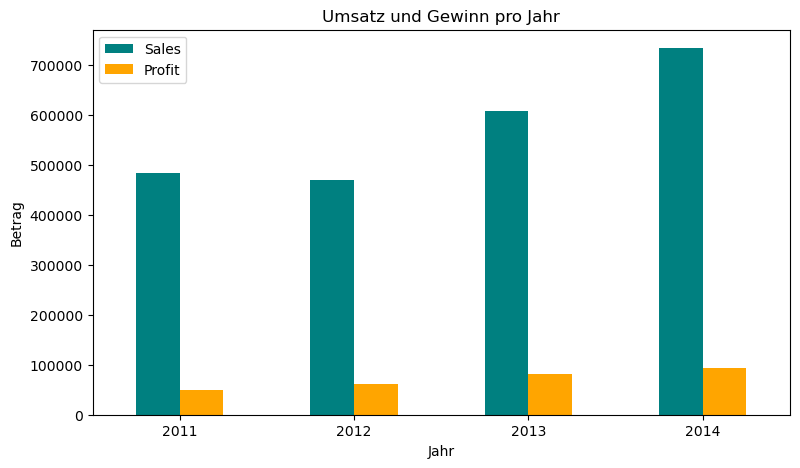

In [20]:
yearly_summary.plot(
    kind="bar",
    figsize=(9, 5),
    color=["teal", "orange"]
)

plt.title("Umsatz und Gewinn pro Jahr")
plt.xlabel("Jahr")
plt.ylabel("Betrag")
plt.xticks(rotation=0)
plt.show()

In [21]:
category_summary = df.groupby("Category")[["Sales", "Profit"]].sum()

category_summary

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


In [22]:
category_summary["Profit Margin %"] = (
    category_summary["Profit"] / category_summary["Sales"] * 100
)

category_summary

,Sales,Profit,Profit Margin %
Category,,,
Furniture,741999.7953,18451.2728,2.486695
Office Supplies,719047.0320,122490.8008,17.035158
Technology,836154.0330,145454.9481,17.395712


In [23]:
subcategory_summary = (
    df.groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
    .sort_values("Profit")
)

subcategory_summary

,Sales,Profit
Sub-Category,,
Tables,206965.5320,-17725.4811
Bookcases,114879.9963,-3472.5560
Supplies,46673.5380,-1189.0995
Fasteners,3024.2800,949.5182
Machines,189238.6310,3384.7569
Labels,12486.3120,5546.2540
Art,27118.7920,6527.7870
Envelopes,16476.4020,6964.1767
Furnishings,91705.1640,13059.1436


In [24]:
subcategory_summary["Profit Margin %"] = (
    subcategory_summary["Profit"]
    / subcategory_summary["Sales"]
    * 100
)

subcategory_summary.round(2)

,Sales,Profit,Profit Margin %
Sub-Category,,,
Tables,206965.53,-17725.48,-8.56
Bookcases,114880.00,-3472.56,-3.02
Supplies,46673.54,-1189.10,-2.55
Fasteners,3024.28,949.52,31.40
Machines,189238.63,3384.76,1.79
Labels,12486.31,5546.25,44.42
Art,27118.79,6527.79,24.07
Envelopes,16476.40,6964.18,42.27
Furnishings,91705.16,13059.14,14.24


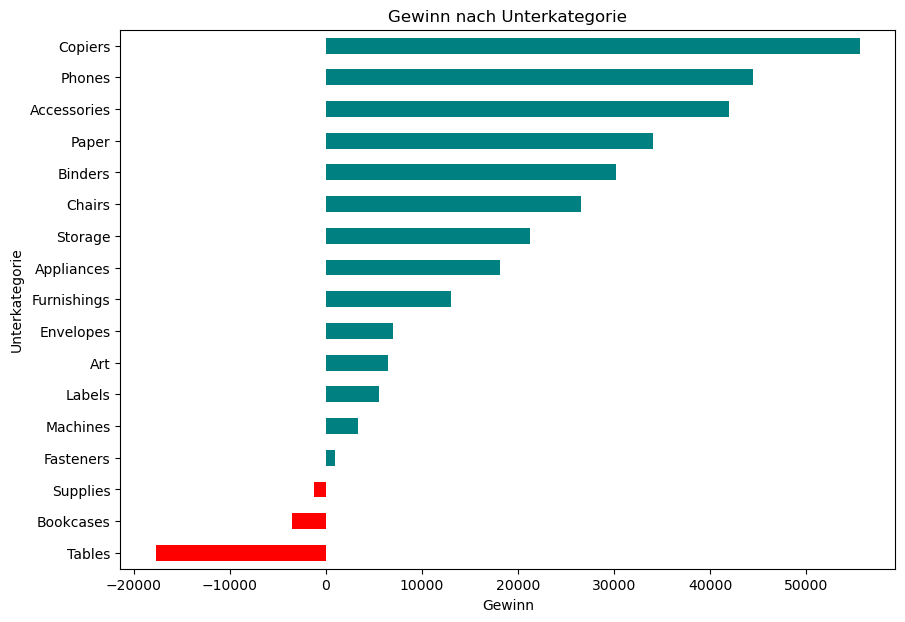

In [25]:
subcategory_summary["Profit"].plot(
    kind="barh",
    figsize=(10, 7),
    color=[
        "red" if profit < 0 else "teal"
        for profit in subcategory_summary["Profit"]
    ]
)

plt.title("Gewinn nach Unterkategorie")
plt.xlabel("Gewinn")
plt.ylabel("Unterkategorie")
plt.show()

In [26]:
df["Discount Group"] = pd.cut(
    df["Discount"],
    bins=[-0.01, 0, 0.2, 0.4, 0.6, 1],
    labels=["0 %", "1–20 %", "21–40 %", "41–60 %", "über 60 %"]
)

discount_summary = df.groupby(
    "Discount Group",
    observed=True
)[["Sales", "Profit"]].sum()

discount_summary

,Sales,Profit
Discount Group,,
0 %,1.087908e+06,320987.6032
1–20 %,8.465222e+05,100785.4745
21–40 %,2.341379e+05,-35817.4655
41–60 %,7.104821e+04,-28944.1944
über 60 %,5.758404e+04,-70614.3961


In [27]:
discount_summary["Profit Margin %"] = (
    discount_summary["Profit"]
    / discount_summary["Sales"]
    * 100
)

discount_summary.round(2)

,Sales,Profit,Profit Margin %
Discount Group,,,
0 %,1087908.47,320987.60,29.51
1–20 %,846522.24,100785.47,11.91
21–40 %,234137.90,-35817.47,-15.30
41–60 %,71048.21,-28944.19,-40.74
über 60 %,57584.04,-70614.40,-122.63


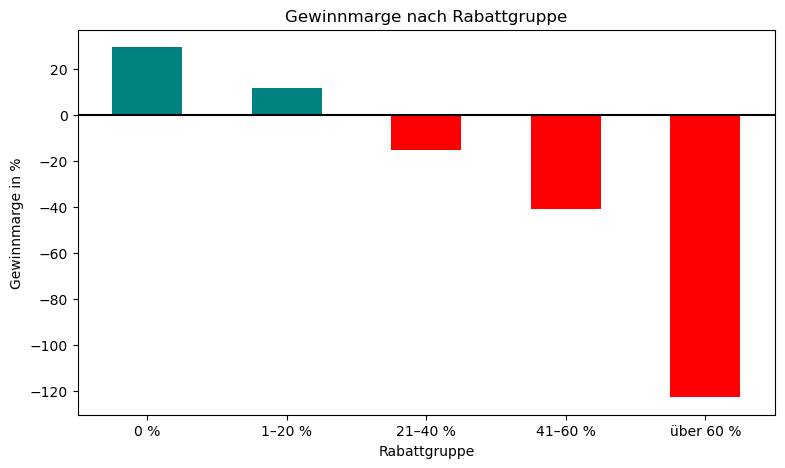

In [28]:
discount_summary["Profit Margin %"].plot(
    kind="bar",
    figsize=(9, 5),
    color=[
        "teal" if margin >= 0 else "red"
        for margin in discount_summary["Profit Margin %"]
    ]
)

plt.title("Gewinnmarge nach Rabattgruppe")
plt.xlabel("Rabattgruppe")
plt.ylabel("Gewinnmarge in %")
plt.axhline(0, color="black")
plt.xticks(rotation=0)
plt.show()

In [29]:
region_summary = (
    df.groupby("Region")[["Sales", "Profit"]]
    .sum()
    .sort_values("Profit", ascending=False)
)

region_summary

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
South,391721.9050,46749.4303
Central,501239.8908,39706.3625


In [30]:
region_summary["Profit Margin %"] = (
    region_summary["Profit"]
    / region_summary["Sales"]
    * 100
)

region_summary.round(2)

,Sales,Profit,Profit Margin %
Region,,,
West,725457.82,108418.45,14.94
East,678781.24,91522.78,13.48
South,391721.90,46749.43,11.93
Central,501239.89,39706.36,7.92


In [31]:
central_subcategories = (
    df[df["Region"] == "Central"]
    .groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
    .sort_values("Profit")
)

central_subcategories

,Sales,Profit
Sub-Category,,
Furnishings,15254.3700,-3906.2168
Tables,39154.9710,-3559.6504
Appliances,23582.0330,-2638.6175
Bookcases,24157.1768,-1997.9043
Machines,26797.3840,-1486.0666
Binders,56923.2820,-1043.6369
Supplies,9467.3720,-661.8881
Fasteners,778.0300,236.6186
Labels,2451.4720,1073.0794


In [32]:
central_discount_analysis = (
    df[df["Region"] == "Central"]
    .groupby("Sub-Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Average_Discount=("Discount", "mean")
    )
    .sort_values("Profit")
)

central_discount_analysis.round(2)

,Sales,Profit,Average_Discount
Sub-Category,,,
Furnishings,15254.37,-3906.22,0.40
Tables,39154.97,-3559.65,0.26
Appliances,23582.03,-2638.62,0.45
Bookcases,24157.18,-1997.90,0.23
Machines,26797.38,-1486.07,0.33
Binders,56923.28,-1043.64,0.51
Supplies,9467.37,-661.89,0.14
Fasteners,778.03,236.62,0.13
Labels,2451.47,1073.08,0.11


In [33]:
top_products_sales = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_sales

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [34]:
top_products_profit = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_profit

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

In [35]:
bottom_products_profit = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values()
    .head(10)
)

bottom_products_profit

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

In [36]:
bottom_product_details = (
    df[df["Product Name"].isin(bottom_products_profit.index)]
    .groupby("Product Name")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Average_Discount=("Discount", "mean"),
        Quantity=("Quantity", "sum")
    )
    .sort_values("Profit")
)

bottom_product_details.round(2)

,Sales,Profit,Average_Discount,Quantity
Product Name,,,,
Cubify CubeX 3D Printer Double Head Print,11099.96,-8879.97,0.53,9
Lexmark MX611dhe Monochrome Laser Printer,16829.90,-4589.97,0.40,18
Cubify CubeX 3D Printer Triple Head Print,7999.98,-3839.99,0.50,4
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.64,-2876.12,0.28,27
Bush Advantage Collection Racetrack Conference Table,9544.72,-1934.40,0.35,33
GBC DocuBind P400 Electric Binding System,17965.07,-1878.17,0.45,27
Cisco TelePresence System EX90 Videoconferencing Unit,22638.48,-1811.08,0.50,6
Martin Yale Chadless Opener Electric Letter Opener,16656.20,-1299.18,0.10,22
Balt Solid Wood Round Tables,6518.75,-1201.06,0.20,19


In [37]:
segment_summary = (
    df.groupby("Segment")[["Sales", "Profit"]]
    .sum()
    .sort_values("Profit", ascending=False)
)

segment_summary["Profit Margin %"] = (
    segment_summary["Profit"]
    / segment_summary["Sales"]
    * 100
)

segment_summary.round(2)

,Sales,Profit,Profit Margin %
Segment,,,
Consumer,1161401.34,134119.21,11.55
Corporate,706146.37,91979.13,13.03
Home Office,429653.15,60298.68,14.03


In [38]:
df["Month"] = df["Order Date"].dt.month

monthly_summary = (
    df.groupby("Month")[["Sales", "Profit"]]
    .sum()
)

monthly_summary.round(2)

,Sales,Profit
Month,,
1,95365.94,9199.27
2,60172.65,10288.90
3,199252.98,26806.57
4,141851.57,13437.81
5,156122.29,22308.51
6,147082.61,20899.33
7,149580.84,13535.38
8,159589.45,21896.72
9,309770.10,37293.19


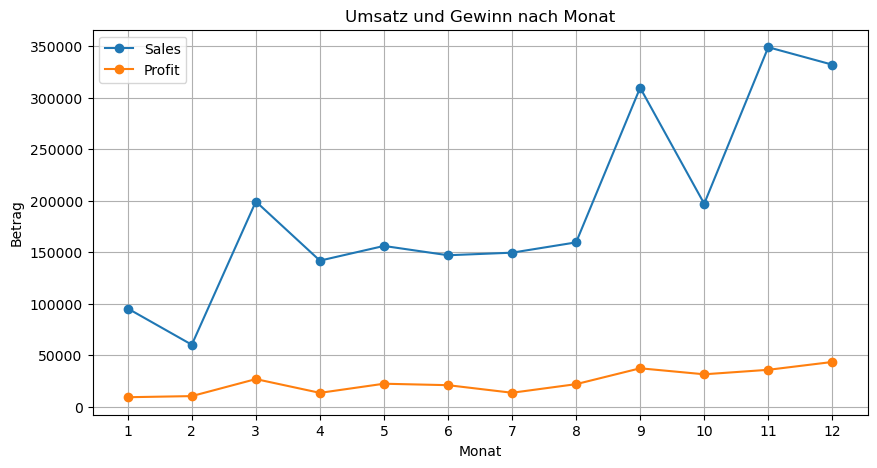

In [39]:
monthly_summary.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Umsatz und Gewinn nach Monat")
plt.xlabel("Monat")
plt.ylabel("Betrag")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [40]:
df["Year-Month"] = df["Order Date"].dt.to_period("M")

monthly_trend = (
    df.groupby("Year-Month")[["Sales", "Profit"]]
    .sum()
)

monthly_trend.head()

,Sales,Profit
Year-Month,,
2011-01,13946.229,2446.7711
2011-02,4810.558,865.7280
2011-03,55691.009,498.7299
2011-04,28295.345,3488.8352
2011-05,23648.287,2738.7096


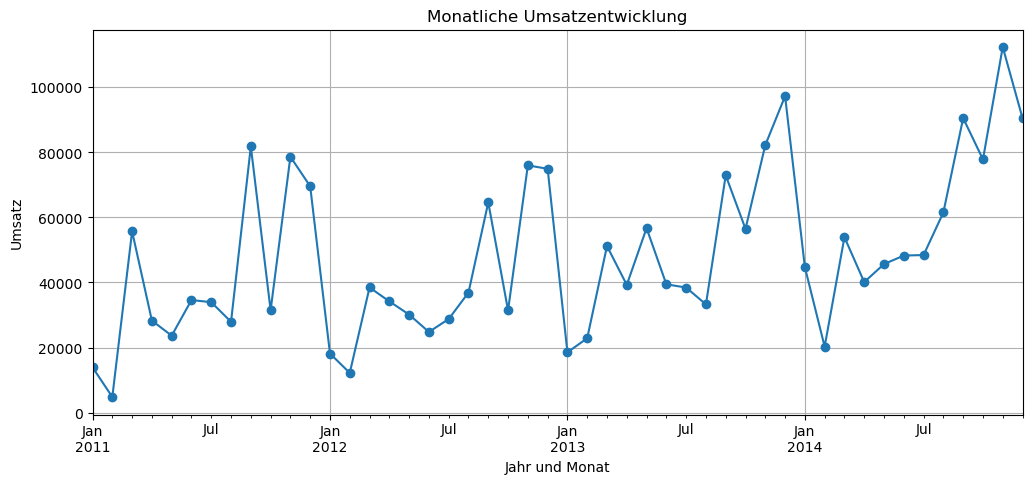

In [41]:
monthly_trend["Sales"].plot(
    kind="line",
    figsize=(12, 5),
    marker="o"
)

plt.title("Monatliche Umsatzentwicklung")
plt.xlabel("Jahr und Monat")
plt.ylabel("Umsatz")
plt.grid(True)
plt.show()

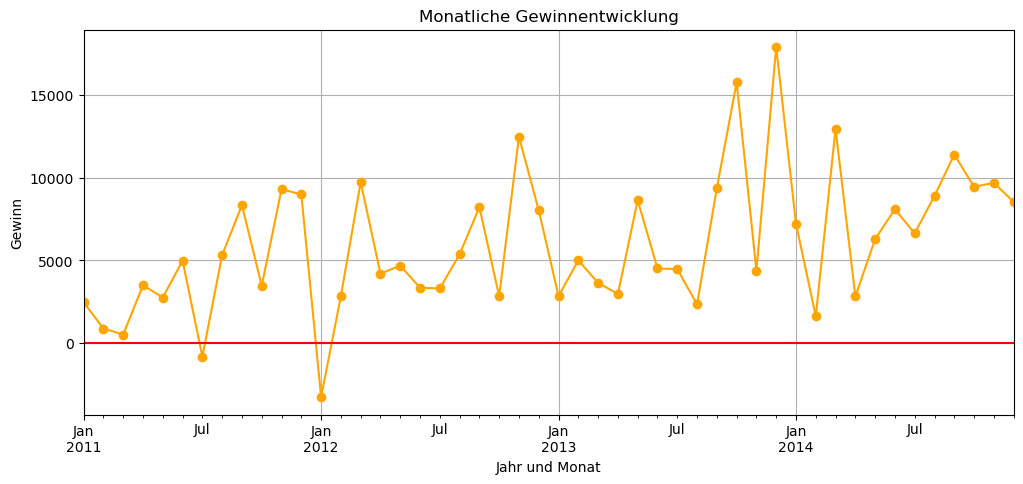

In [42]:
monthly_trend["Profit"].plot(
    kind="line",
    figsize=(12, 5),
    marker="o",
    color="orange"
)

plt.title("Monatliche Gewinnentwicklung")
plt.xlabel("Jahr und Monat")
plt.ylabel("Gewinn")
plt.axhline(0, color="red")
plt.grid(True)
plt.show()

In [43]:
loss_months = monthly_trend[
    monthly_trend["Profit"] < 0
]

loss_months.round(2)

,Sales,Profit
Year-Month,,
2011-07,33946.39,-841.48
2012-01,18174.08,-3281.01


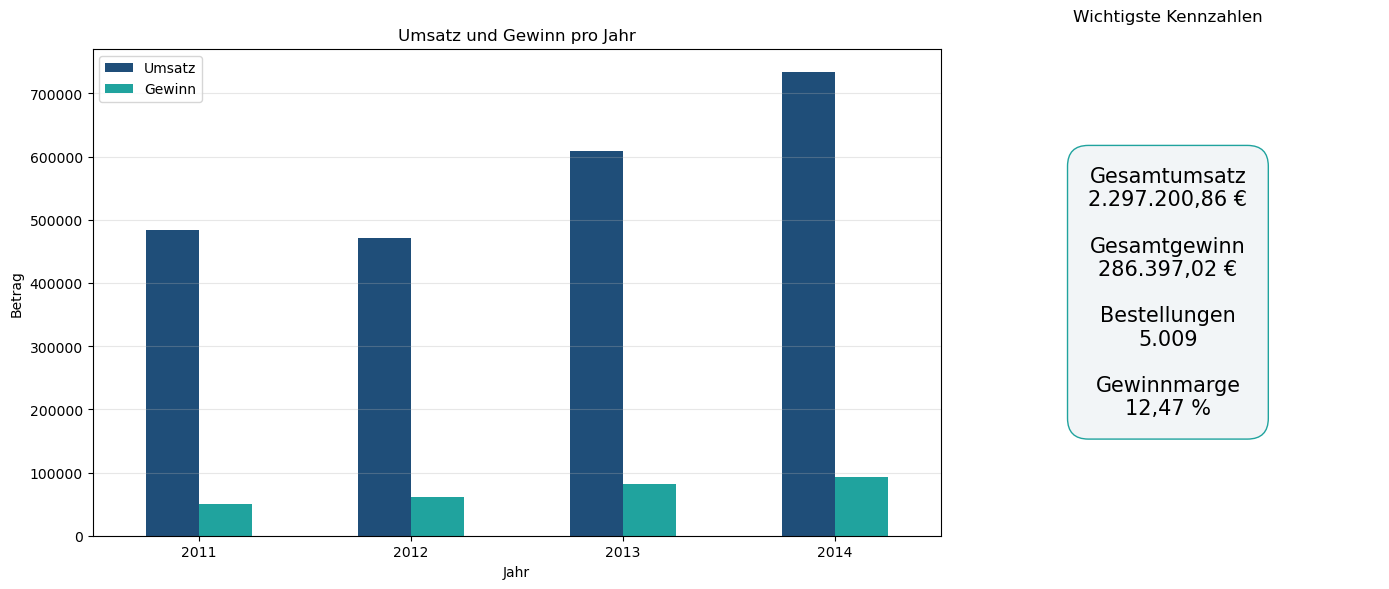

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Kennzahlen berechnen
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
profit_margin = (total_profit / total_sales) * 100

# Bestelldatum umwandeln und Jahr erstellen
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Year"] = df["Order Date"].dt.year

# Umsatz und Gewinn pro Jahr berechnen
yearly_summary = df.groupby("Year")[["Sales", "Profit"]].sum()

# Funktion für deutsche Zahlenformatierung
def german_number(value, decimals=2):
    return (
        f"{value:,.{decimals}f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )

# Abbildung mit zwei Bereichen erstellen
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    gridspec_kw={"width_ratios": [2, 1]}
)

# Balkendiagramm
yearly_summary.plot(
    kind="bar",
    ax=ax1,
    color=["#1f4e79", "#20a39e"]
)

ax1.set_title("Umsatz und Gewinn pro Jahr")
ax1.set_xlabel("Jahr")
ax1.set_ylabel("Betrag")
ax1.tick_params(axis="x", rotation=0)
ax1.legend(["Umsatz", "Gewinn"])
ax1.grid(axis="y", alpha=0.3)

# Kennzahlen rechts anzeigen
ax2.axis("off")
ax2.set_title("Wichtigste Kennzahlen", pad=20)

kpi_text = (
    f"Gesamtumsatz\n{german_number(total_sales)} €\n\n"
    f"Gesamtgewinn\n{german_number(total_profit)} €\n\n"
    f"Bestellungen\n{german_number(total_orders, 0)}\n\n"
    f"Gewinnmarge\n{german_number(profit_margin)} %"
)

ax2.text(
    0.5,
    0.5,
    kpi_text,
    ha="center",
    va="center",
    fontsize=15,
    bbox=dict(
        boxstyle="round,pad=1",
        facecolor="#f2f5f7",
        edgecolor="#20a39e"
    )
)

# Layout verbessern und Bild speichern
plt.tight_layout()

plt.savefig(
    "superstore_linkedin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()